In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , roc_auc_score , recall_score , precision_score
import warnings
warnings.filterwarnings('ignore')

## Dataset Load

In [2]:
df = pd.read_csv("gym_members_exercise_tracking.csv")

## Feature Enginnering

In [3]:
def bmi_category(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_Category'] = df['BMI'].apply(bmi_category)

In [4]:
df['Heart_Rate_Reserve'] = df['Max_BPM'] - df['Resting_BPM']

In [5]:
df['HR_Intensity'] = df['Avg_BPM'] / df['Max_BPM']

In [6]:
def intensity_category(value):
    if value < 0.70:
        return 'Low'
    elif value < 0.85:
        return 'Moderate'
    else:
        return 'High'

df['Workout_Intensity'] = df['HR_Intensity'].apply(intensity_category)

In [7]:
df['Calories_Per_Hour'] = (df['Calories_Burned'] / df['Session_Duration (hours)']) 

In [8]:
df['Workout_Load'] = (df['Session_Duration (hours)'] * df['Avg_BPM'])

In [9]:
df['Weekly_Workout_Hours'] = (df['Workout_Frequency (days/week)']* df['Session_Duration (hours)'])

In [10]:
df['Risk_Score'] = 0

df.loc[df['BMI'] >= 30, 'Risk_Score'] += 1
df.loc[df['Fat_Percentage'] >= 30, 'Risk_Score'] += 1
df.loc[df['HR_Intensity'] >= 0.85, 'Risk_Score'] += 1
df.loc[df['Resting_BPM'] >= 70, 'Risk_Score'] += 1
df.loc[df['Workout_Load'] >= 200, 'Risk_Score'] += 1

In [11]:
def fitness_risk(score):

    if score <= 1:
        return 'Low'

    elif score == 2:
        return 'Moderate'

    else:
        return 'High'


df['Fitness_Risk'] = df['Risk_Score'].apply(fitness_risk)

In [12]:
df.head().T

,0,1,2,3,4
Age,56,46,32,25,38
Gender,Male,Female,Female,Male,Male
Weight (kg),88.3,74.9,68.1,53.2,46.1
Height (m),1.71,1.53,1.66,1.7,1.79
Max_BPM,180,179,167,190,188
Avg_BPM,157,151,122,164,158
Resting_BPM,60,66,54,56,68
Session_Duration (hours),1.69,1.3,1.11,0.59,0.64
Calories_Burned,1313.0,883.0,677.0,532.0,556.0
Workout_Type,Yoga,HIIT,Cardio,Strength,Strength


# Data Spliting

In [13]:
x = df.drop(['Fitness_Risk','Risk_Score', 'Calories_Burned','Calories_Per_Hour'], axis=1)

risk_mapping = {'Low': 0,'Moderate': 1,'High': 2}

y = df['Fitness_Risk'].map(risk_mapping)

## Performing Train Test Split

In [15]:
xtrain , xtest , ytrain , ytest = train_test_split(x,y,test_size = .25, random_state = 42)

## Encoding Apply


In [17]:
encoder = OneHotEncoder(sparse_output=False, drop='first')

categorical_columns = xtrain.select_dtypes(include='object').columns

for column in categorical_columns:

    train_encoded = encoder.fit_transform(xtrain[[column]])
    test_encoded = encoder.transform(xtest[[column]])

    train_df = pd.DataFrame(train_encoded,
                            columns=encoder.get_feature_names_out([column]),
                            index=xtrain.index)

    test_df = pd.DataFrame(test_encoded,
                           columns=encoder.get_feature_names_out([column]),
                           index=xtest.index)

    xtrain = pd.concat([xtrain, train_df], axis=1)
    xtest = pd.concat([xtest, test_df], axis=1)

    xtrain.drop(column, axis=1, inplace=True)
    xtest.drop(column, axis=1, inplace=True)

## Performing Random Forest Classifier 

Best Parameters For Random Forest:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}


Training Score For Random Forest : 100.0
Testing Score For Random Forest : 95.08196721311475
Accuracy Score For Random Forest : 95.08196721311475


Classification Report For Random Forest:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       160
           1       0.94      0.84      0.89        58
           2       0.92      0.88      0.90        26

    accuracy                           0.95       244
   macro avg       0.94      0.91      0.92       244
weighted avg       0.95      0.95      0.95       244

Sensitivity : 0.909814323607427
Specificity : 0.9637877741606656
ROC-AUC Score : 0.9934780567883194




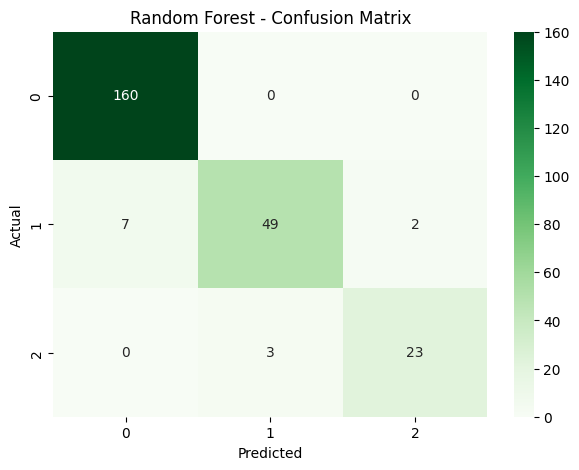

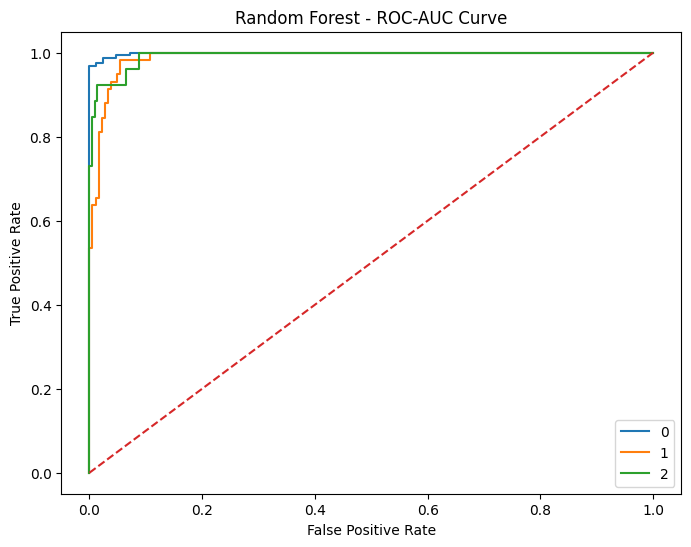

In [28]:
# Random Forest

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    rf,
    rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

model_rf = rf_grid.fit(xtrain, ytrain)

# Best Parameters

print("Best Parameters For Random Forest:")
print(model_rf.best_params_)
print("\n")

# Training Score

print("Training Score For Random Forest :",
      model_rf.score(xtrain, ytrain) * 100)

# Testing Score

print("Testing Score For Random Forest :",
      model_rf.score(xtest, ytest) * 100)


# Predictions

ytest_pred = model_rf.predict(xtest)

# Accuracy Score

accuracy_rf = accuracy_score(ytest, ytest_pred)

print("Accuracy Score For Random Forest :",
      accuracy_rf * 100)

print("\n")

# Classification Report
print("Classification Report For Random Forest:")
print(classification_report(ytest, ytest_pred))



# Confusion Matrix
cm_rf = confusion_matrix(ytest, ytest_pred)



# Sensitivity
sensitivity_rf = recall_score(ytest,ytest_pred,average='macro')
print("Sensitivity :", sensitivity_rf)



# Specificity

specificity_list = []

for i in range(len(cm_rf)):

    true_negative = cm_rf.sum() - (
        cm_rf[i, :].sum()
        + cm_rf[:, i].sum()
        - cm_rf[i, i]
    )

    false_positive = cm_rf[:, i].sum() - cm_rf[i, i]

    specificity = true_negative / (
        true_negative + false_positive
    )

    specificity_list.append(specificity)

specificity_rf = np.mean(specificity_list)

print("Specificity :", specificity_rf)

# ROC-AUC Score

ytest_probability = model_rf.predict_proba(xtest)

roc_auc_rf = roc_auc_score(
    ytest,
    ytest_probability,
    multi_class='ovr',
    average='macro'
)

print("ROC-AUC Score :", roc_auc_rf)

print("\n")



# Confusion Matrix

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf,annot=True,fmt='d',cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ROC-AUC Curve

ytest_binary = label_binarize(ytest, classes=model_rf.classes_)

plt.figure(figsize=(8, 6))

for i in range(len(model_rf.classes_)):

    fpr, tpr, _ = roc_curve(ytest_binary[:, i],ytest_probability[:, i])
    plt.plot(fpr,tpr,label=model_rf.classes_[i])

plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest - ROC-AUC Curve")

plt.legend()
plt.show()